First, mount your Google Drive:

In [11]:
# Import necessary libraries for the assignment
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import requests
from PIL import Image
import pandas as pd
import seaborn as sns
from urllib.request import urlretrieve
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import shutil

import sys
import platform

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

# Set current working directory
HOME = os.getcwd()
print(f"Working directory: {HOME}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully!
TensorFlow version: 2.19.0
OpenCV version: 4.12.0
NumPy version: 2.0.2
Working directory: /content


In [12]:
drive_path = '/content/drive/My Drive/GitHub/aai_521_computer_vision'

# Check if the new directory exists, if not, create it
if not os.path.exists(os.path.dirname(drive_path)):
    os.makedirs(os.path.dirname(drive_path))
    print(f"Created new directory: {os.path.dirname(drive_path)}")
else:
    print(f'{drive_path} already exists!')

# Change the current working directory to the new Google Drive path
%cd {os.path.dirname(drive_path)}
# Clone the repository
print(f"Cloning repository into: {drive_path}")
!git clone https://github.com/marstonsward/aai_521_computer_vision.git
# Change back to the original working directory (optional, but good practice)
%cd /content

/content/drive/My Drive/GitHub/aai_521_computer_vision already exists!
/content/drive/My Drive/GitHub
Cloning repository into: /content/drive/My Drive/GitHub/aai_521_computer_vision
fatal: destination path 'aai_521_computer_vision' already exists and is not an empty directory.
/content


In [34]:
# Static utility functions for the assignment

def display_images_with_masks(images, masks, titles=None, figsize=(15, 5)):
    """
    Display images alongside their segmentation masks
    """
    n_images = len(images)
    fig, axes = plt.subplots(2, n_images, figsize=figsize)

    if n_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_images):
        # Display original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original Image {i+1}' if titles is None else f'Original {titles[i]}')
        axes[0, i].axis('off')

        # Display mask
        axes[1, i].imshow(masks[i], cmap='viridis')
        axes[1, i].set_title(f'Segmentation Mask {i+1}' if titles is None else f'Mask {titles[i]}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def preprocess_image(image, target_size=(128, 128)):
    """
    Preprocess image to target size and normalize
    """
    # Resize image
    image_resized = tf.image.resize(image, target_size)
    # Convert to float32 and normalize to [0, 1]
    image_normalized = tf.cast(image_resized, tf.float32) / 255.0
    return image_normalized

def download_and_extract_dataset(url, destination_folder):
    """
    Download and extract a dataset from a URL
    """
    filename = url.split('/')[-1]
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    filepath = os.path.join(destination_folder, filename)

    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urlretrieve(url, filepath)
        print(f"Downloaded {filename}")

    # Extract if it's a zip file
    if filename.endswith('.zip'):
        extract_path = os.path.join(destination_folder, filename[:-4])
        if not os.path.exists(extract_path):
            print(f"Extracting {filename}...")
            with zipfile.ZipFile(filepath, 'r') as zip_ref:
                zip_ref.extractall(destination_folder)
            print(f"Extracted to {extract_path}")
        return extract_path

    return filepath

def plot_training_curves(history, metrics=['loss'], figsize=(12, 4)):
    """
    Plot training curves from training history
    """
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize)

    if n_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Training {metric}')
            if f'val_{metric}' in history.history:
                axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
            axes[i].set_title(f'{metric.capitalize()} Curve')
            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(metric.capitalize())
            axes[i].legend()
            axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def display_dataset_samples(dataset, n_samples=3):
    """
    Display sample images and masks from a processed dataset
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 8))

    if n_samples == 1:
        axes = axes.reshape(2, 1)

    images_to_display = []
    masks_to_display = []

    for i, (image, mask) in enumerate(dataset.take(n_samples)):
        images_to_display.append(image.numpy())
        masks_to_display.append(mask.numpy().squeeze()) # Squeeze to remove the channel dimension if it exists

    for i in range(n_samples):
        # Display original image
        axes[0, i].imshow(images_to_display[i])
        axes[0, i].set_title(f'Sample Image {i+1}')
        axes[0, i].axis('off')

        # Display mask
        # Use a colormap suitable for masks, e.g., 'viridis' or 'gray'
        axes[1, i].imshow(masks_to_display[i], cmap='viridis')
        axes[1, i].set_title(f'Sample Mask {i+1}')
        axes[1, i].axis('off')


    plt.tight_layout()
    plt.show()


print("Utility functions defined successfully!")


# Preprocessing function for the Oxford-IIIT Pet dataset
def read_and_preprocess(data):
    """
    Preprocess the oxford_iiit_pet dataset samples
    - Resize images and masks to 128x128
    - Normalize images to [0,1] range
    - Adjust mask values from {1,2,3} to {0,1,2}
    """
    # Resize the image to 128x128
    input_image = tf.image.resize(data['image'], [128, 128])

    # Resize the segmentation mask to 128x128 using nearest neighbor to preserve labels
    input_mask = tf.image.resize(
        data['segmentation_mask'],
        [128, 128],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    # Convert image to float32 and normalize to [0, 1]
    input_image = tf.image.convert_image_dtype(input_image, tf.float32)

    # Clip values to ensure they are within [0, 1]
    input_image = tf.clip_by_value(input_image, 0.0, 1.0)


    # Adjust mask values: {1,2,3} -> {0,1,2}
    # (1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border)
    input_mask = tf.cast(input_mask, tf.int32)
    input_mask -= 1

    # Ensure mask values are in correct range
    input_mask = tf.clip_by_value(input_mask, 0, 2)

    return input_image, input_mask

print("✅ Preprocessing function defined!")
print("This function will:")
print("  • Resize images and masks to 128×128")
print("  • Normalize images to [0,1] range")
print("  • Convert mask values from {1,2,3} to {0,1,2}")
print("  • Use nearest neighbor for mask resizing to preserve labels")

Utility functions defined successfully!
✅ Preprocessing function defined!
This function will:
  • Resize images and masks to 128×128
  • Normalize images to [0,1] range
  • Convert mask values from {1,2,3} to {0,1,2}
  • Use nearest neighbor for mask resizing to preserve labels


In [14]:
# GPU and Environment Configuration for M4 MacBook Pro and Google Colab

def setup_gpu_environment():
    """
    Configure GPU acceleration for both M4 MacBook Pro (Metal) and Google Colab
    """
    print("Setting up GPU environment...")
    print(f"Python version: {sys.version}")
    print(f"Platform: {platform.platform()}")
    print(f"TensorFlow version: {tf.__version__}")

    # Check if running in Google Colab
    try:
        import google.colab
        IN_COLAB = True
        print("🔍 Detected: Google Colab environment")
    except ImportError:
        IN_COLAB = False
        print("🔍 Detected: Local environment")

    # Configure GPU settings
    if IN_COLAB:
        # Google Colab GPU setup
        print("📱 Configuring for Google Colab...")
        physical_devices = tf.config.list_physical_devices('GPU')
        if len(physical_devices) > 0:
            print(f"✅ GPU available: {physical_devices}")
            # Enable memory growth to prevent OOM errors
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print("✅ GPU memory growth enabled")
        else:
            print("⚠️  No GPU detected in Colab. Check runtime type.")

    else:
        # Local Mac M4 setup
        print("🍎 Configuring for MacBook Pro M4...")

        # Check for Metal (M4 GPU) support
        try:
            # List all available devices
            physical_devices = tf.config.list_physical_devices()
            print(f"Available devices: {physical_devices}")

            # Check specifically for Metal/GPU devices
            gpu_devices = tf.config.list_physical_devices('GPU')
            if len(gpu_devices) > 0:
                print(f"✅ Metal GPU detected: {gpu_devices}")
                # Configure memory growth for Metal GPU
                for device in gpu_devices:
                    tf.config.experimental.set_memory_growth(device, True)
                print("✅ Metal GPU memory growth enabled")
            else:
                print("⚠️  No Metal GPU detected")

            # Verify Metal plugin is working
            with tf.device('/GPU:0' if len(gpu_devices) > 0 else '/CPU:0'):
                test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                result = tf.matmul(test_tensor, test_tensor)
                device_used = result.device
                print(f"✅ Test computation device: {device_used}")

        except Exception as e:
            print(f"⚠️  GPU setup warning: {e}")
            print("Falling back to CPU")

    # Print final device configuration
    print("\n📋 Final Device Configuration:")
    print(f"Logical devices: {tf.config.list_logical_devices()}")

    # Test mixed precision if GPU is available
    if len(tf.config.list_physical_devices('GPU')) > 0:
        try:
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print("✅ Mixed precision enabled (float16)")
        except Exception as e:
            print(f"⚠️  Mixed precision not available: {e}")

    return IN_COLAB

# Run the setup
IN_COLAB = setup_gpu_environment()

# Set global variables for later use
if IN_COLAB:
    # Colab-specific settings
    BATCH_SIZE = 32
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using Colab optimized settings")
else:
    # M4 Mac optimized settings
    BATCH_SIZE = 16  # Smaller batch size for local training
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using M4 Mac optimized settings")

print(f"✅ Environment setup complete!")
print(f"Batch size: {BATCH_SIZE}")
print(f"Prefetch size: {PREFETCH_SIZE}")

Setting up GPU environment...
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow version: 2.19.0
🔍 Detected: Google Colab environment
📱 Configuring for Google Colab...
✅ GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU memory growth enabled

📋 Final Device Configuration:
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled (float16)
📝 Using Colab optimized settings
✅ Environment setup complete!
Batch size: 32
Prefetch size: -1


In [16]:
file_path = '/content/drive/MyDrive/GitHub/aai_521_computer_vision/module_3/Assignment3_Steps_and_KeyPoints.txt'

try:
    with open(file_path, 'r') as f:
        assignment_content = f.read()
        # You can print the content if you want to see it
        # print(assignment_content)
        print("Successfully read the assignment file.")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully read the assignment file.


In [15]:
# PART 1 - OBJECT SEGMENTATION
# a) Load the oxford_iiit_pet dataset

import os
import time
from tqdm import tqdm

print("Loading Oxford-IIIT Pet Dataset...")
print("Note: First time download may take several minutes (dataset is ~800MB)")

# Check if dataset already exists
dataset_path = './tensorflow_datasets/oxford_iiit_pet/4.0.0'
if os.path.exists(dataset_path):
    print("✅ Dataset already downloaded locally")
else:
    print("📥 Dataset not found locally. Starting download...")
    print("This may take 5-10 minutes depending on your internet connection.")

start_time = time.time()

try:
    # Load the dataset with segmentation masks (using the correct version)
    dataset, info = tfds.load('oxford_iiit_pet:4.0.0',
                             with_info=True,
                             as_supervised=False,
                             data_dir='./tensorflow_datasets',
                             download=True)  # Explicitly enable download

    download_time = time.time() - start_time
    print(f"✅ Dataset loaded successfully in {download_time:.1f} seconds")

    print(f"\n📊 Dataset Information:")
    print(f"Dataset name: {info.name}")
    print(f"Version: {info.version}")
    print(f"Description: {info.description[:200]}...")
    print(f"Available splits: {list(dataset.keys())}")

    # Get dataset splits
    train_dataset = dataset['train']
    test_dataset = dataset['test']

    # Display basic dataset information
    print(f"\n📈 Dataset Statistics:")
    print(f"Training samples: {info.splits['train'].num_examples}")
    print(f"Test samples: {info.splits['test'].num_examples}")
    print(f"Total samples: {info.splits['train'].num_examples + info.splits['test'].num_examples}")
    print(f"Number of classes: {info.features['label'].num_classes}")
    print(f"Number of classes: {info.features['label'].num_classes}")  # Show first 10 classes

    # Show the structure of a sample
    print(f"\n🔍 Sample Structure:")
    for sample in train_dataset.take(1):
        print(f"Sample keys: {list(sample.keys())}")
        print(f"Image shape: {sample['image'].shape}")
        print(f"Image dtype: {sample['image'].dtype}")
        print(f"Segmentation mask shape: {sample['segmentation_mask'].shape}")
        print(f"Segmentation mask dtype: {sample['segmentation_mask'].dtype}")
        print(f"Label: {sample['label'].numpy()}")
        print(f"Species (0=cat, 1=dog): {sample['species'].numpy()}")
        break

    print(f"\n✅ Oxford-IIIT Pet dataset loaded successfully!")

except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Trying alternative approach...")

    # Alternative: Try without specifying data_dir
    try:
        dataset, info = tfds.load('oxford_iiit_pet:4.0.0',
                                 with_info=True,
                                 as_supervised=False,
                                 download=True)
        print("✅ Dataset loaded using default directory")
    except Exception as e2:
        print(f"❌ Alternative approach also failed: {e2}")
        print("Please check your internet connection and try again.")

Loading Oxford-IIIT Pet Dataset...
Note: First time download may take several minutes (dataset is ~800MB)
📥 Dataset not found locally. Starting download...
This may take 5-10 minutes depending on your internet connection.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling tensorflow_datasets/oxford_iiit_pet/incomplete.WC95N3_4.0.0/oxford_iiit_pet-train.tfrecord*...:   0%…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling tensorflow_datasets/oxford_iiit_pet/incomplete.WC95N3_4.0.0/oxford_iiit_pet-test.tfrecord*...:   0%|…

Dataset oxford_iiit_pet downloaded and prepared to tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
✅ Dataset loaded successfully in 90.7 seconds

📊 Dataset Information:
Dataset name: oxford_iiit_pet
Version: 4.0.0
Description: The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
images for each class. The images have large variations in scale, pose and
lighting. All images have an associated groun...
Available splits: ['train', 'test']

📈 Dataset Statistics:
Training samples: 3680
Test samples: 3669
Total samples: 7349
Number of classes: 37
Class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']...

🔍 Sample Structure:
Sample keys: ['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species']
Image shape: (500, 500, 3)
Image dtype: <dtype: 'uint8'>
Segmentation mask shape: (500, 500, 1)
Segmentation mask d

## Print the class names in the dataset

In [23]:
print(f"Number of classes: {info.features['label'].num_classes}")
print("Classes:")
for index, name in enumerate(info.features['label'].names):
    print(f"{index + 1:02} - {name}")

Number of classes: 37
Classes:
01 - Abyssinian
02 - american_bulldog
03 - american_pit_bull_terrier
04 - basset_hound
05 - beagle
06 - Bengal
07 - Birman
08 - Bombay
09 - boxer
10 - British_Shorthair
11 - chihuahua
12 - Egyptian_Mau
13 - english_cocker_spaniel
14 - english_setter
15 - german_shorthaired
16 - great_pyrenees
17 - havanese
18 - japanese_chin
19 - keeshond
20 - leonberger
21 - Maine_Coon
22 - miniature_pinscher
23 - newfoundland
24 - Persian
25 - pomeranian
26 - pug
27 - Ragdoll
28 - Russian_Blue
29 - saint_bernard
30 - samoyed
31 - scottish_terrier
32 - shiba_inu
33 - Siamese
34 - Sphynx
35 - staffordshire_bull_terrier
36 - wheaten_terrier
37 - yorkshire_terrier


### Examine the raw images

Displaying 5 images from the raw training dataset in a single subplot:


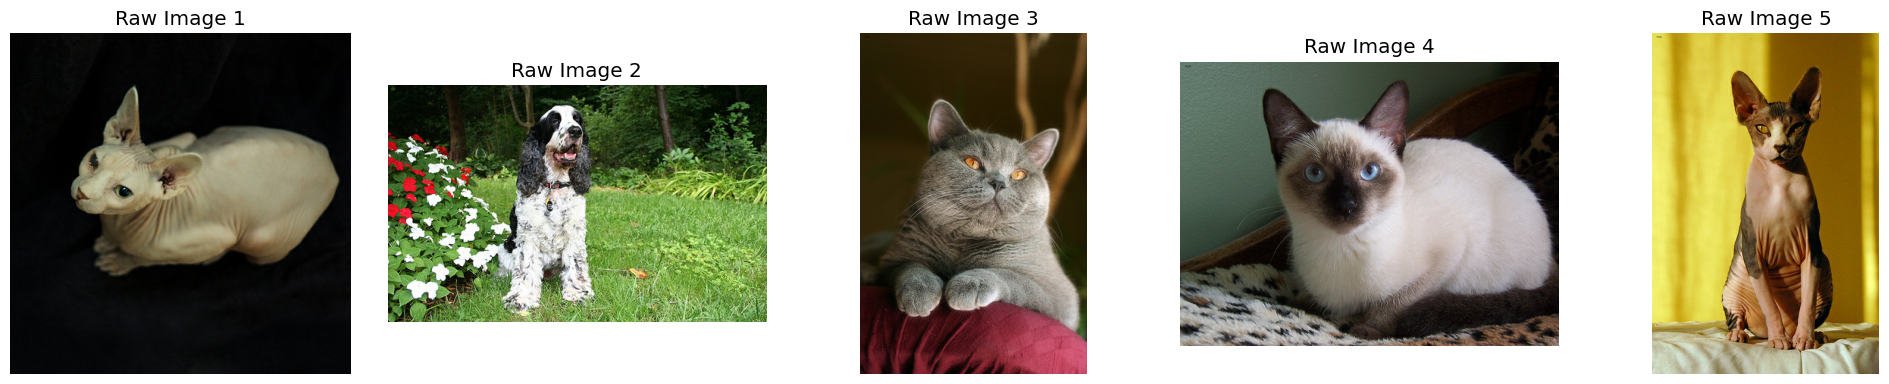

In [38]:
import matplotlib.pyplot as plt

print("Displaying 5 images from the raw training dataset in a single subplot:")

# Get the raw training dataset
raw_train_dataset = dataset['train']

# Create a figure and a set of subplots with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4)) # Adjust figsize as needed

# Take the first 5 samples and plot them in the subplots
for i, sample in enumerate(raw_train_dataset.take(5)):
    # Access the raw image from the sample dictionary
    image = sample['image'].numpy()

    # Display the image in the corresponding subplot axis
    axes[i].imshow(image)
    axes[i].set_title(f"Raw Image {i+1}")
    axes[i].axis('off')

plt.tight_layout() # Adjust layout to prevent titles from overlapping
plt.show()

In [39]:
train = dataset['train'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test = dataset['test'].map(read_and_preprocess)

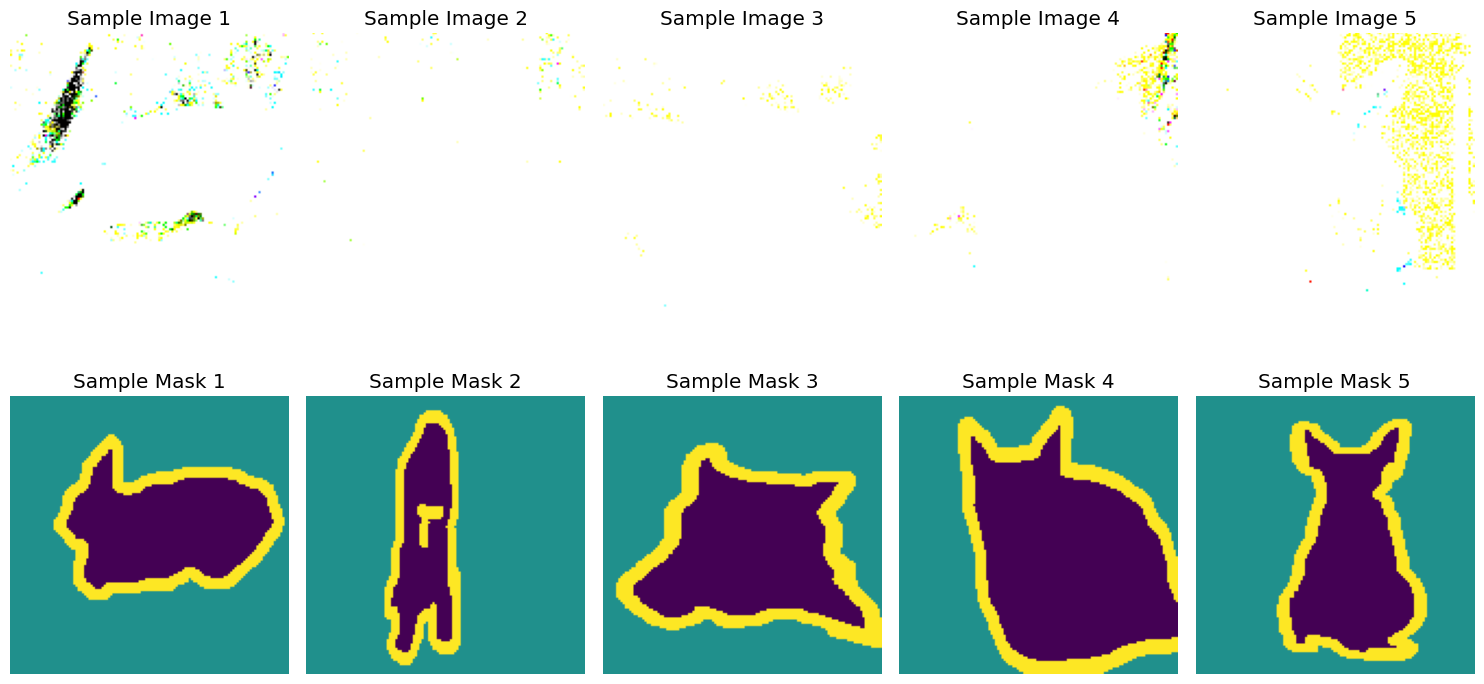

In [40]:
import warnings
import matplotlib.image as mpimg

# Ignore the specific matplotlib.image clipping warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib.image')

# Display the first 5 samples from the processed training dataset
display_dataset_samples(train, n_samples=5)

# Optionally, reset warnings after the call if needed
# warnings.filterwarnings("default")

In [ ]:
# b) Create the segmentation mask
# Show some images from dataset and their segmented version

**Part 2- Annotation**

In [ ]:
# Install mrcnn

In [ ]:
# Get data from here https://github.com/experiencor/raccoon_dataset


In [ ]:
# Look into data
# Plot some samples here


In [ ]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray
from mrcnn.utils import Dataset

# class that defines and loads the raccoon dataset
class RaccoonDataset(Dataset):
	# load the dataset definitions
	def load_dataset(self, dataset_dir, is_train=True):
		# define one class
		self.add_class("raccoon_dataset", 1, "raccoon")
		# define data locations
		images_dir = dataset_dir + '/images/'
		annotations_dir = dataset_dir + '/annotations/raccoon-'
		# find all images
		for filename in listdir(images_dir):
			# extract image id
			image_id = filename[8:-4]
			# skip bad images
			if image_id in ['00090']:
				continue
			# skip all images after 150 if we are building the train set
			if is_train and int(image_id) >= 150:
				continue
			# skip all images before 150 if we are building the test/val set
			if not is_train and int(image_id) < 150:
				continue
			img_path = images_dir + filename
			ann_path = annotations_dir + image_id + '.xml'
			# add to dataset
			self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

	# extract bounding boxes from an annotation file
	def extract_boxes(self, filename):
		# load and parse the file
		tree = ElementTree.parse(filename)
		# get the root of the document
		root = tree.getroot()
		# extract each bounding box
		boxes = list()
		for box in root.findall('.//bndbox'):
			xmin = int(box.find('xmin').text)
			ymin = int(box.find('ymin').text)
			xmax = int(box.find('xmax').text)
			ymax = int(box.find('ymax').text)
			coors = [xmin, ymin, xmax, ymax]
			boxes.append(coors)
		# extract image dimensions
		width = int(root.find('.//size/width').text)
		height = int(root.find('.//size/height').text)
		return boxes, width, height

	# load the masks for an image
	def load_mask(self, image_id):
		# get details of image
		info = self.image_info[image_id]
		# define box file location
		path = info['annotation']
		# load XML
		#path = '/content/raccoon_dataset/annotations/raccoon-'+image_id   #Added by me
		boxes, w, h = self.extract_boxes(path)
		# create one array for all masks, each on a different channel
		masks = zeros([h, w, len(boxes)], dtype='uint8')
		# create masks
		class_ids = list()
		for i in range(len(boxes)):
			box = boxes[i]
			row_s, row_e = box[1], box[3]
			col_s, col_e = box[0], box[2]
			masks[row_s:row_e, col_s:col_e, i] = 1
			class_ids.append(self.class_names.index('raccoon'))
		return masks, asarray(class_ids, dtype='int32')

	# load an image reference
	def image_reference(self, image_id):
		info = self.image_info[image_id]
		return info['path']

# train set
train_set = RaccoonDataset()
train_set.load_dataset('raccoon_dataset', is_train=True)
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset('raccoon_dataset', is_train=False)
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

In [ ]:
# load an image
# Use the function above to create the image and its mask

**Part 3- YOLO**




You can see how YOLO has been improved in the last few versions on COCO: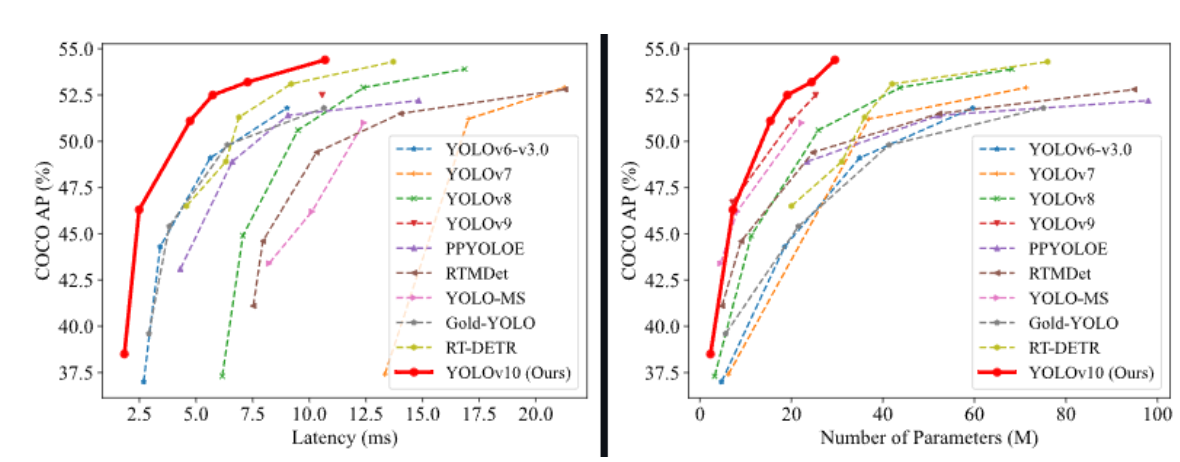

In [ ]:
# a- Create annotation
# You can upload the file using ![title](filename.jpeg)
# import image module



In [ ]:
#b- Download required tools
import os
HOME = os.getcwd()
!pip install -U ultralytics

In [ ]:
#c- Test the model out of box
from ultralytics import YOLO
model = YOLO() # Insert model here
model.predict(source="https://ultralytics.com/images/bus.jpg", conf=0.25, save=True)

In [ ]:
from IPython.display import Image
Image(filename= ........ ) # Modify this code

In [ ]:
#d- Apply model here
!yolo task=detect .... data=african-wildlife.yaml    #Modify this code

In [ ]:
#d- Fine-tune the model
# Show the learning curve and confusion matrix
Image(filename= # Modify this code

In [ ]:
# e- Explain what you see in the learning curves and confusion matrix.